In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint 
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs
import cx_Oracle

In [2]:
#connect to Oracle database 
con = cx_Oracle.connect('VICTORIA/Begin1025!')
cur = con.cursor()

#SQL query 
cur.execute('''select freq_A, freq_T, freq_GC FROM beeGenes''')
results = cur.fetchall()

#create numpy array with extracted data
X = np.array(results)

#close connection and cursor 
cur.close()
con.close()


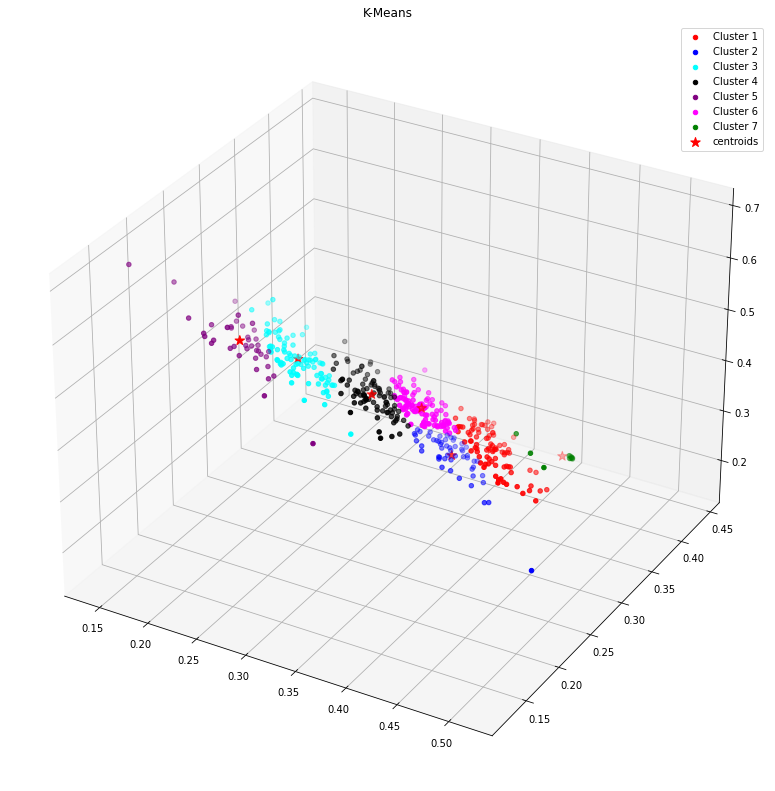

In [3]:
#K-Means 
km = KMeans(n_clusters = 7, 
            init = 'random', 
            n_init = 10, 
            max_iter = 500, 
            tol = 1e-4, 
            random_state = 0)

y_km = km.fit_predict(X)

#set up plots 
fig = plt.figure(figsize = (14, 14))
ax = fig.add_subplot(111, projection = '3d')

#plotting
colors = ['red', 'blue', 'aqua', 'black', 'purple', 'magenta', 'green']

for i in range(7):
    ax.scatter(X[y_km == i, 0], 
               X[y_km == i, 1], 
               X[y_km == i, 2], 
               c = colors[i], 
               marker = 'o', 
               s = 20,
               label = f'Cluster {i+1}')
    
#plot centroids 
centroids = km.cluster_centers_
ax.scatter(km.cluster_centers_[:, 0], 
           km.cluster_centers_[:, 1], 
           km.cluster_centers_[:, 2], 
           c = 'red', 
           marker = '*', 
           s = 100, 
           label='centroids')

#final details to plot 
ax.set_title('K-Means')
ax.legend(loc='upper right')
plt.show()